### Business Context

'All You Need' Supermarket is planning for the year-end sale. They want to launch a new offer - gold membership, that gives a 20% discount on all purchases, for only \$499 which is \$999 on other days. It will be valid only for existing customers and the campaign through phone calls is currently being planned for them. The upper management are a firm believer in the power of data and feels that the best way to reduce the cost of the campaign is to make a predictive model which will classify customers who might purchase the offer. The predictive model will be built using the data gathered during last year's campaign.

### Objective
The supermarket wants to predict the likelihood of the customer giving a positive response and wants to identify the different factors which affect the customer's response. As a data scientist at this supermarket, you need to analyze the data provided to identify these factors and then build a prediction model to predict the probability of a customer will give a positive response. Also, in order to ensure the model achieves the best performance, the model performance has to be improved using hyperparameter tuning and by preventing data leakage. Finally, pipelines have to be used to make the model production ready.

### Data Description

- Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise
- ID - Unique ID of each customer
- Year_Birth - Age of the customer
- Complain - 1 if the customer complained in the last 2 years
- Dt_Customer - date of customer's enrollment with the company
- Education - customer's level of education
- Marital - customer's marital status
- Kidhome - number of small children in customer's household
- Teenhome - number of teenagers in customer's household
- Income - customer's yearly household income
- MntFishProducts - the amount spent on fish products in the last 2 years
- MntMeatProducts - the amount spent on meat products in the last 2 years
- MntFruits - the amount spent on fruits products in the last 2 years
- MntSweetProducts - amount spent on sweet products in the last 2 years
- MntWines - the amount spent on wine products in the last 2 years
- MntGoldProds - the amount spent on gold products in the last 2 years
- NumDealsPurchases - number of purchases made with discount
- NumCatalogPurchases - number of purchases made using catalog (buying goods to be shipped through the mail)
- NumStorePurchases - number of purchases made directly in stores
- NumWebPurchases - number of purchases made through the company's website
- NumWebVisitsMonth - number of visits to company's website in the last month
- Recency - number of days since the last purchase


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import(
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV)

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier)
from xgboost import XGBClassifier

from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [3]:
df = pd.read_excel('marketing_data.xlsx')
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.000,0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.000,0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.000,0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0


In [4]:
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

(None, (2240, 22))

df.describe().T

### Checking for duplicates

In [5]:
df.duplicated().sum()

0

### Checking for missing values

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Response                0
Complain                0
dtype: int64

* Missing values are in the Income field

## Feature Engineering

In [7]:
data = df.copy()

In [8]:
data.drop(['ID'], axis=1, inplace=True)

In [9]:
data['Age'] = 2016 - pd.to_datetime(data['Year_Birth'], 
                                    format='%Y').apply(
    lambda x: x.year)
data['Age'].sort_values()

562      20
1824     20
697      21
1468     21
964      21
       ... 
1740     75
2171     76
2233    116
827     117
513     123
Name: Age, Length: 2240, dtype: int64

- We can see that there are 3 observations with ages greater than 100 i.e. 116, 117 and 123 which is highly unlikely to be true.
- We can drop the observations with age greater than 100

In [10]:
data[data['Age']>100]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
513,1893,2n Cycle,Single,60182.000,0,1,5/17/14,23,8,0,5,7,0,2,1,1,0,2,4,0,0,123
827,1899,PhD,Together,83532.000,0,0,9/26/13,36,755,144,562,104,64,224,1,4,6,4,1,0,0,117
2233,1900,2n Cycle,Divorced,36640.000,1,0,9/26/13,99,15,6,8,7,4,25,1,2,1,2,5,0,1,116


In [11]:
data.drop(data[data['Age']>100].index, inplace=True)

In [12]:
data[data['Age']>100]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age


#### Using Dt_customer tp add features to the data

In [13]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'])

In [14]:
# verify date changed
data.head(3)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1970,Graduation,Divorced,84835.000,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,46
1,1961,Graduation,Single,57091.000,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,1,0,55
2,1958,Graduation,Married,67267.000,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,58


In [15]:
# Extracting registration year from the date
data['Reg_year'] = data['Dt_Customer'].apply(lambda x: x.year)

# Extracting registration quarter from the date
data['Reg_quarter'] = data['Dt_Customer'].apply(lambda x: x.quarter)

#Extracting registration month from the date
data['Reg_month'] = data['Dt_Customer'].apply(lambda x: x.month)

#Extracting registration week from the date
data['Reg_week'] = data['Dt_Customer'].apply(lambda x:x.day//7)

In [16]:
data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week
0,1970,Graduation,Divorced,84835.000,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,46,2014,2,6,2
1,1961,Graduation,Single,57091.000,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,1,0,55,2014,2,6,2
2,1958,Graduation,Married,67267.000,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,58,2014,2,5,1
3,1967,Graduation,Together,32474.000,1,1,2014-11-05,0,10,0,1,0,0,0,1,1,0,2,7,0,0,49,2014,4,11,0
4,1989,Graduation,Single,21474.000,1,0,2014-08-04,0,6,16,24,11,0,34,2,3,1,2,7,1,0,27,2014,3,8,0


#### List categorical variables

In [17]:
cat_col=[
    'Education',
    'Marital_Status',
    'Kidhome',
    'Teenhome',
    'Complain',
    'Response',
    'Reg_year',
    'Reg_quarter',
    'Reg_month',
    'Reg_week'
]

for col in cat_col:
    print(data[col].value_counts())
    print('-'*40)

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64
----------------------------------------
Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64
----------------------------------------
Kidhome
0    1291
1     898
2      48
Name: count, dtype: int64
----------------------------------------
Teenhome
0    1156
1    1029
2      52
Name: count, dtype: int64
----------------------------------------
Complain
0    2217
1      20
Name: count, dtype: int64
----------------------------------------
Response
0    1903
1     334
Name: count, dtype: int64
----------------------------------------
Reg_year
2013    1187
2014     556
2012     494
Name: count, dtype: int64
----------------------------------------
Reg_quarter
4    596
1    580
2    545
3    516
Name: count, dtype: int64
--------------------------

In [18]:
# Replpce 2n Cycle with Master
data['Education'] = data['Education'].replace('2n Cycle','Master')

In [19]:
# Replacing YOLO, Alone, Absurd with single and Together with Married
data['Marital_Status'] = data['Marital_Status'].replace(
    ['YOLO', 'Alone', 'Absurd'], 'Single')
data['Marital_Status'] = data['Marital_Status'].replace(
    ['Together'], 'Married')

In [20]:
cat_col=[
    'Education',
    'Marital_Status']

for col in cat_col:
    print(data[col].value_counts())
    print('-'*40)

Education
Graduation    1127
Master         571
PhD            485
Basic           54
Name: count, dtype: int64
----------------------------------------
Marital_Status
Married     1443
Single       486
Divorced     231
Widow         77
Name: count, dtype: int64
----------------------------------------


#### Add total amount spent column

In [21]:
data["Total_Amount_Spent"] = data[
    [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
    ]
].sum(axis=1)

In [22]:
data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week,Total_Amount_Spent
0,1970,Graduation,Divorced,84835.000,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,1,0,46,2014,2,6,2,1190
1,1961,Graduation,Single,57091.000,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,1,0,55,2014,2,6,2,577
2,1958,Graduation,Married,67267.000,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,58,2014,2,5,1,251
3,1967,Graduation,Married,32474.000,1,1,2014-11-05,0,10,0,1,0,0,0,1,1,0,2,7,0,0,49,2014,4,11,0,11
4,1989,Graduation,Single,21474.000,1,0,2014-08-04,0,6,16,24,11,0,34,2,3,1,2,7,1,0,27,2014,3,8,0,91


## EDA

In [23]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [24]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [25]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

### Univariate analysis

#### Income

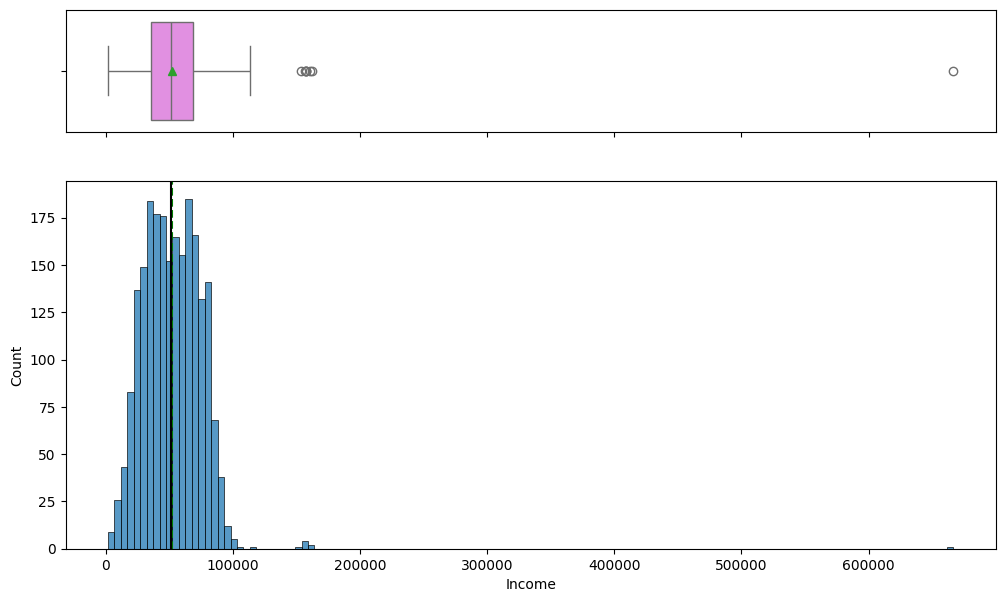

In [26]:
histogram_boxplot(data,'Income')

In [27]:
data[data['Income']>200000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week,Total_Amount_Spent
527,1977,Graduation,Married,666666.000,1,0,2013-02-06,23,9,14,18,8,1,12,4,3,1,3,6,0,0,39,2013,1,2,0,62


In [28]:
# Drop record with income over 200000
data.drop(index=data[data['Income']>200000].index, inplace=True)

In [29]:
data[data['Income']>200000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week,Total_Amount_Spent


#### MntMeatProducts

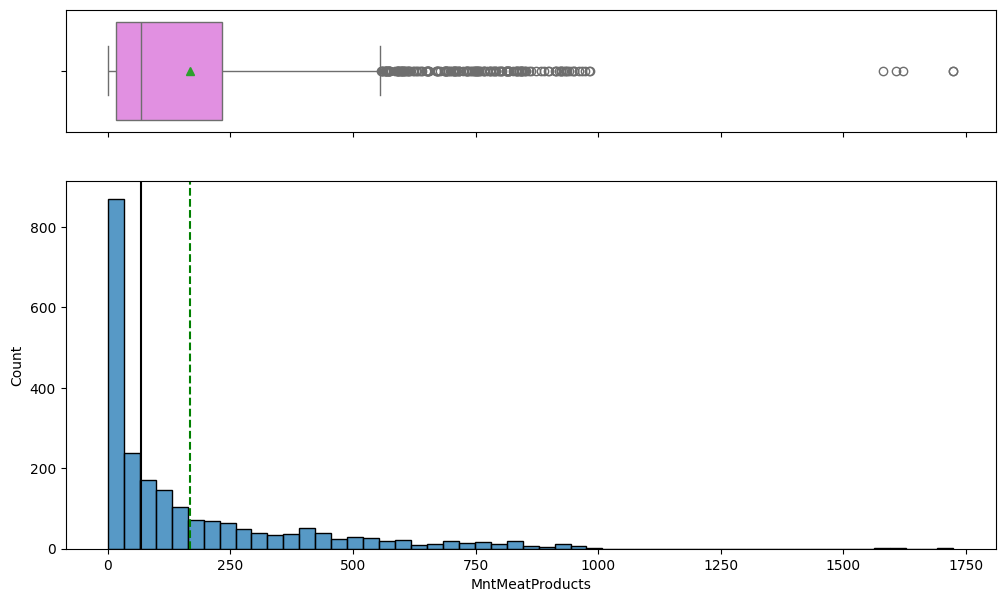

In [30]:
histogram_boxplot(data,'MntMeatProducts')

In [31]:
# Checking the largest 10 values of amount spent on meat products
data['MntMeatProducts'].nlargest(10)

325     1725
961     1725
497     1622
1213    1607
2204    1582
1921     984
53       981
994      974
2021     968
1338     961
Name: MntMeatProducts, dtype: int64

In [32]:
data[data['MntMeatProducts']>1500]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week,Total_Amount_Spent
325,1977,Graduation,Married,157146.000,0,0,2013-04-29,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,39,2013,2,4,4,1730
497,1982,PhD,Married,160803.000,0,0,2012-04-08,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,34,2012,2,4,1,1717
961,1979,Graduation,Married,2447.000,1,0,2013-06-01,42,1,1,1725,1,1,1,15,0,28,0,1,0,0,37,2013,2,6,0,1730
1213,1978,Master,Married,NaN,0,0,2012-12-08,53,32,2,1607,12,4,22,0,0,0,1,0,0,0,38,2012,4,12,1,1679
2204,1973,PhD,Married,157243.000,0,1,2014-01-03,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,43,2014,1,1,0,1608


- The values for MntMeatProducts for these 5 observations need not be incorrect
- So, dropping them will lead us to loss of information
- Let's cap them with next highest value

In [33]:
data['MntMeatProducts'].clip(upper=984, inplace=True)

#### MntSweetProducts

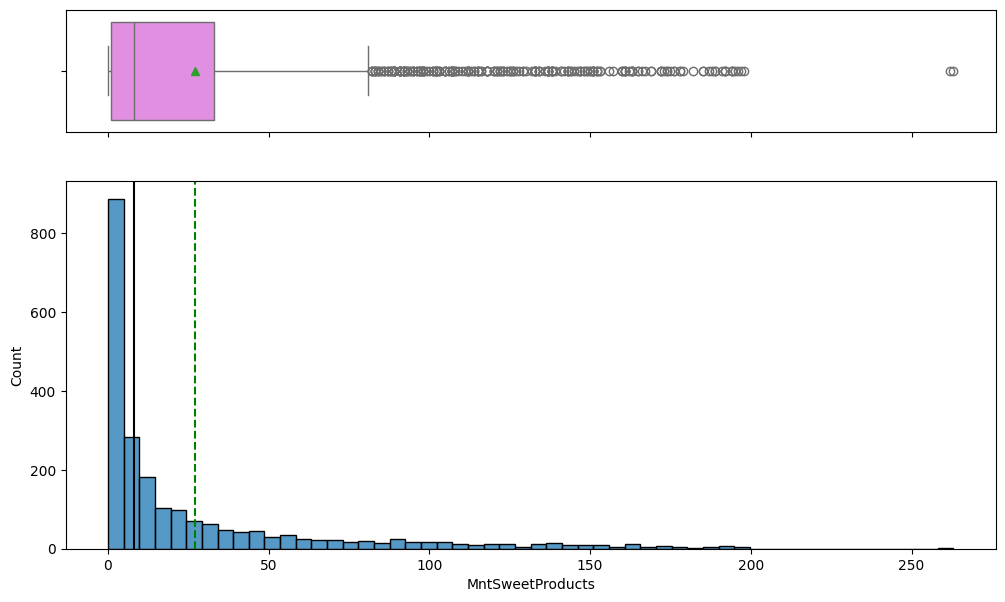

In [34]:
histogram_boxplot(data, 'MntSweetProducts')

In [35]:
data[data['MntSweetProducts']>200]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week,Total_Amount_Spent
210,1945,PhD,Single,113734.000,0,0,2014-05-28,9,6,2,3,1,262,3,0,27,0,0,1,0,0,71,2014,2,5,4,277
449,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,1,3,3,263,362,0,27,0,0,1,0,0,30,2013,1,2,2,637


- The values for MntSweetProducts for these 2 observations need not be incorrect
- So, dropping them will lead us to loss of information
- Let's cap them with next highest value

In [36]:
data['MntSweetProducts'].clip(upper=198, inplace=True)

#### MntGoldProds

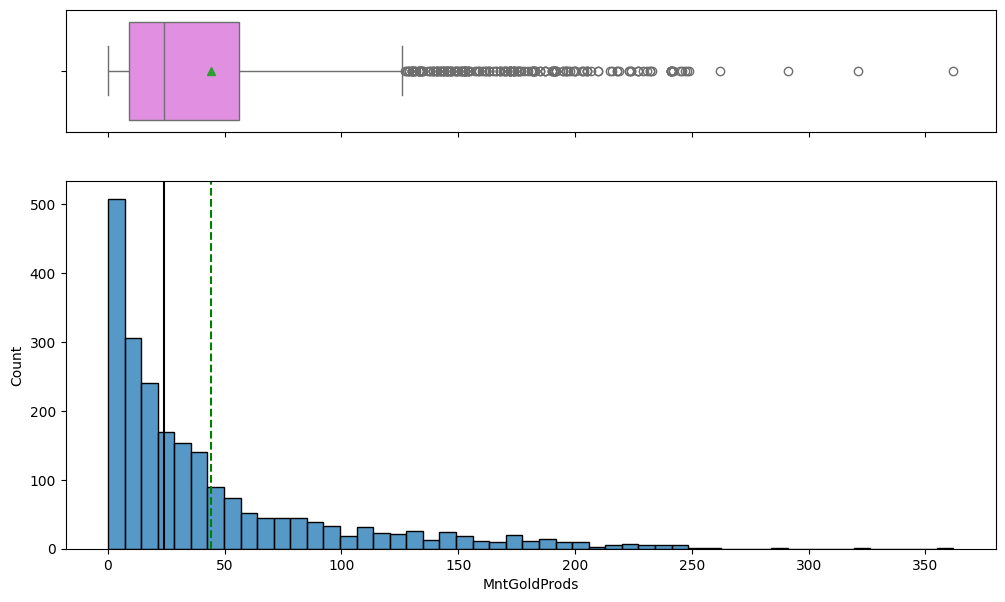

In [37]:
histogram_boxplot(data, 'MntGoldProds')

In [38]:
data[data['MntGoldProds']>250]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week,Total_Amount_Spent
14,1969,Graduation,Married,4428.000,0,1,2013-05-10,0,16,4,12,2,4,321,0,25,0,0,1,0,0,47,2013,2,5,1,359
60,1982,Master,Single,6560.000,0,0,2013-12-12,2,67,11,26,4,3,262,0,1,0,1,17,0,0,34,2013,4,12,1,373
449,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,1,3,3,198,362,0,27,0,0,1,0,0,30,2013,1,2,2,637
2063,1966,PhD,Single,7144.000,0,2,2013-07-12,92,81,4,33,5,2,291,0,23,1,1,0,0,0,50,2013,3,7,1,416


- The values for MntGoldProds for these 4 observations need not be incorrect
- So, dropping them will lead us to loss of information
- Let's cap them with next highest value

In [39]:
data['MntGoldProds'].clip(upper=250, inplace=True)

#### MntWines

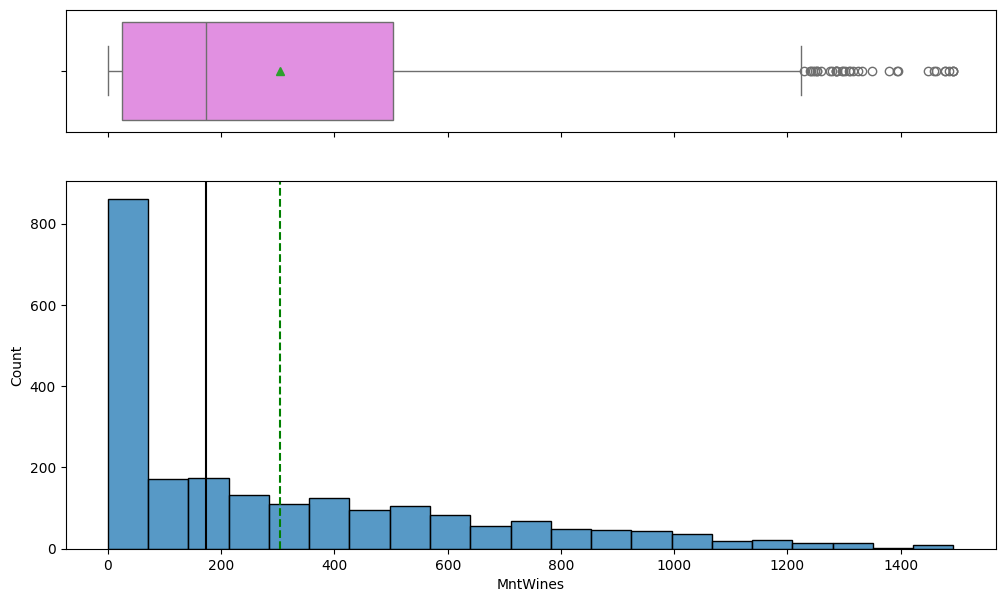

In [40]:
histogram_boxplot(data, 'MntWines')

- The distribution for the amount spent on wines is highly skewed to the right
- As the median of the distribution is less than 200, more than 50% of customers have spent less than 200 on wines.
- There are some outliers on the right end of the boxplot but we will not treat them as some variation is always expected in real-world scenarios for variables like amount spent.

#### NumWebPurchases

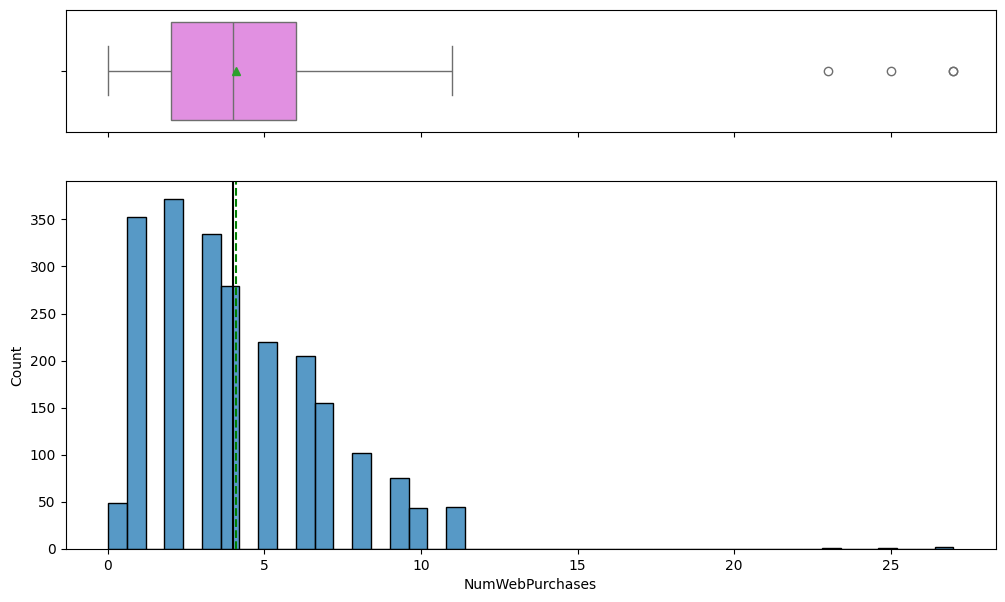

In [41]:
histogram_boxplot(data,'NumWebPurchases')

- The values for NumWebPurchases for these 4 observations need not be incorrect
- So, dropping them will lead us to loss of information
- Let's cap them with next highest value

In [42]:
data[data['NumWebPurchases']>15]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week,Total_Amount_Spent
14,1969,Graduation,Married,4428.000,0,1,2013-05-10,0,16,4,12,2,4,250,0,25,0,0,1,0,0,47,2013,2,5,1,359
210,1945,PhD,Single,113734.000,0,0,2014-05-28,9,6,2,3,1,198,3,0,27,0,0,1,0,0,71,2014,2,5,4,277
449,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,1,3,3,198,250,0,27,0,0,1,0,0,30,2013,1,2,2,637
2063,1966,PhD,Single,7144.000,0,2,2013-07-12,92,81,4,33,5,2,250,0,23,1,1,0,0,0,50,2013,3,7,1,416


In [43]:
data['NumWebPurchases'].clip(upper=11, inplace=True)

#### NumWebVisitsMonth

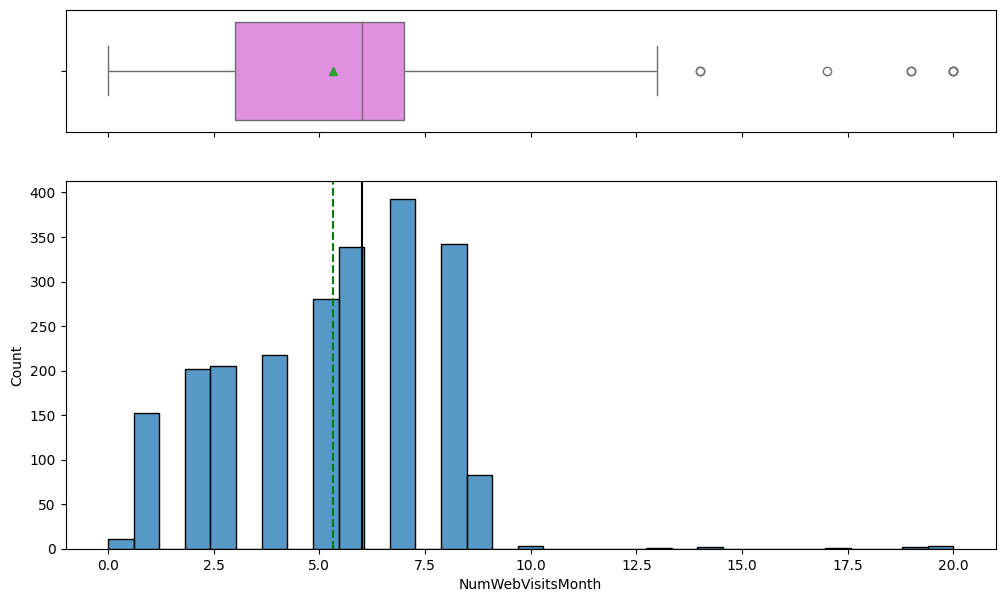

In [44]:
histogram_boxplot(data, 'NumWebVisitsMonth')

- The distribution for the number of visits in a month is skewed and has some outliers at the right end.
- We will not treat this as this represents a general market trend

#### NumCatalogPurchases

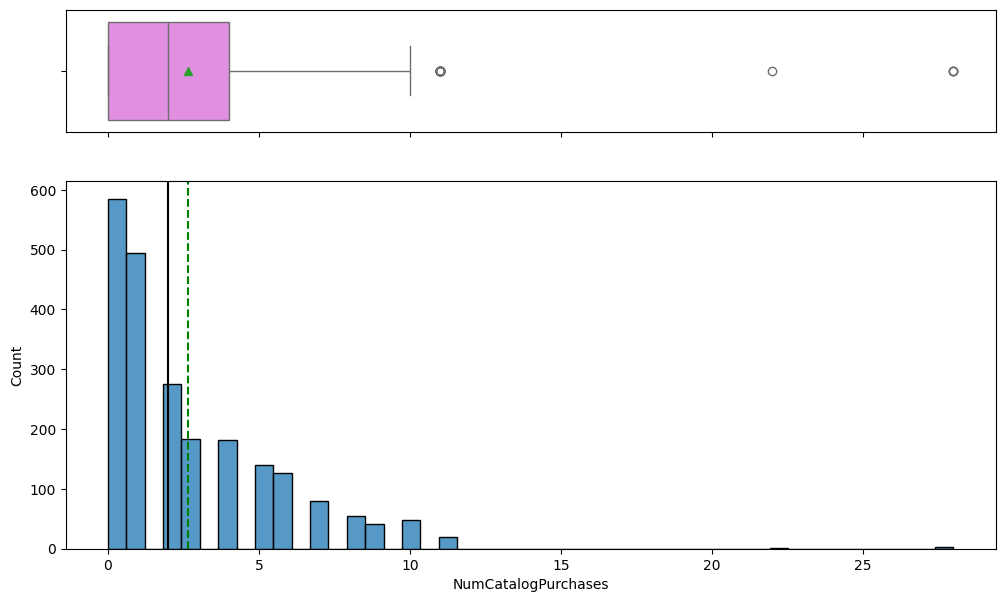

In [45]:
histogram_boxplot(data, 'NumCatalogPurchases')

- The most number of observations are for 0 catalog purchases.
- The median of the distribution is 2 i.e. 50% of customers have 2 or less than 2 catalog purchases. 
- We can see that there is two extreme observation in the variable. We can cap these values to the next highest number of purchases.

In [46]:
data[data['NumCatalogPurchases']>15]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age,Reg_year,Reg_quarter,Reg_month,Reg_week,Total_Amount_Spent
325,1977,Graduation,Married,157146.000,0,0,2013-04-29,13,1,0,984,2,1,1,0,0,28,0,1,0,0,39,2013,2,4,4,1730
497,1982,PhD,Married,160803.000,0,0,2012-04-08,21,55,16,984,17,3,4,15,0,28,1,0,0,0,34,2012,2,4,1,1717
961,1979,Graduation,Married,2447.000,1,0,2013-06-01,42,1,1,984,1,1,1,15,0,28,0,1,0,0,37,2013,2,6,0,1730
2204,1973,PhD,Married,157243.000,0,1,2014-01-03,98,20,2,984,1,2,1,15,0,22,0,0,0,0,43,2014,1,1,0,1608


In [47]:
data['NumCatalogPurchases'].clip(upper=11, inplace=True)

#### Complain

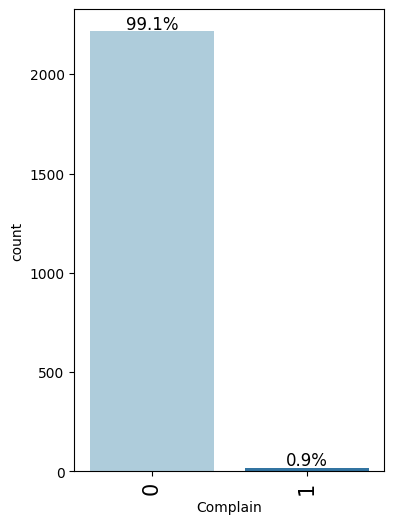

In [48]:
labeled_barplot(data, 'Complain', perc=True)

- Approx 99% of customers had no complaint in the last 2 years. This might be because the company provides good services or might be due to the lack of feedback options for customers.

#### Teenhome

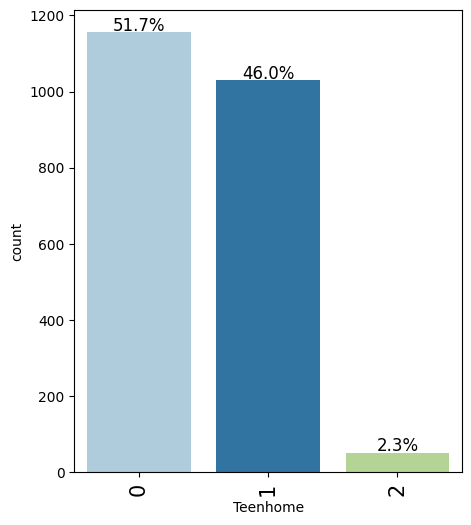

In [49]:
labeled_barplot(data, 'Teenhome', perc=True)

- Majority of the customers i.e. ~52% customers have no teen at home
- There are very few customers, only ~2%, with a number of teens greater than 1 

#### Response

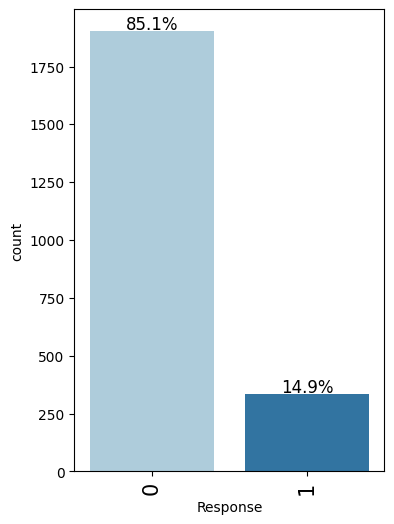

In [50]:
labeled_barplot(data, 'Response', perc=True)

- Approx 85% customer's response was NO in the last campaign.
- This shows that the distribution of classes in the target variable is imbalanced. We have only ~15% observations where response is YES.

### Bivariate Analysis

#### Mnt fields vs Response

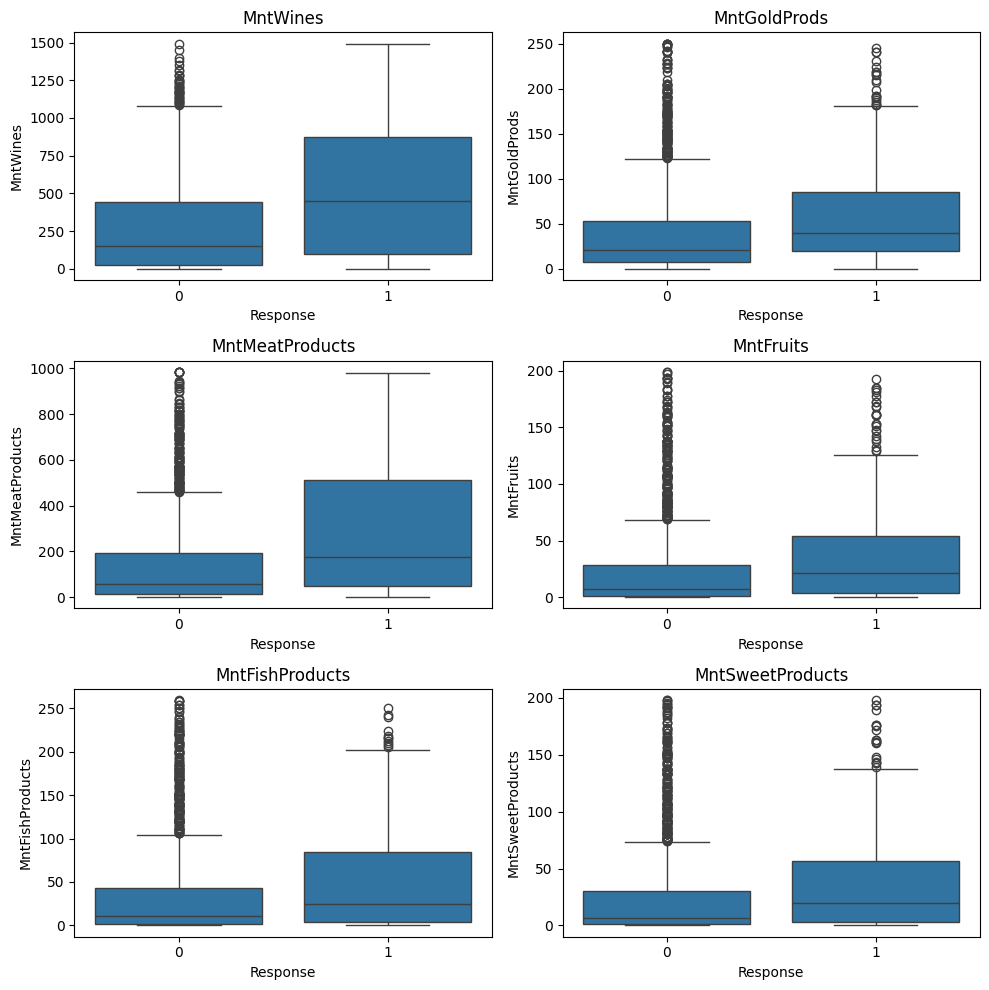

In [51]:
cols = data[
    [
        'MntWines',
        'MntGoldProds',
        'MntMeatProducts',
        'MntFruits',
        'MntFishProducts',
        'MntSweetProducts'
    ]
].columns.tolist()
plt.figure(figsize=(10,10))

for i, variable in enumerate(cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=data["Response"], y=data[variable])
    plt.tight_layout()
    plt.title(variable)
plt.show()

#### Reg_year and Reg_month vs Total_Amount_Spent

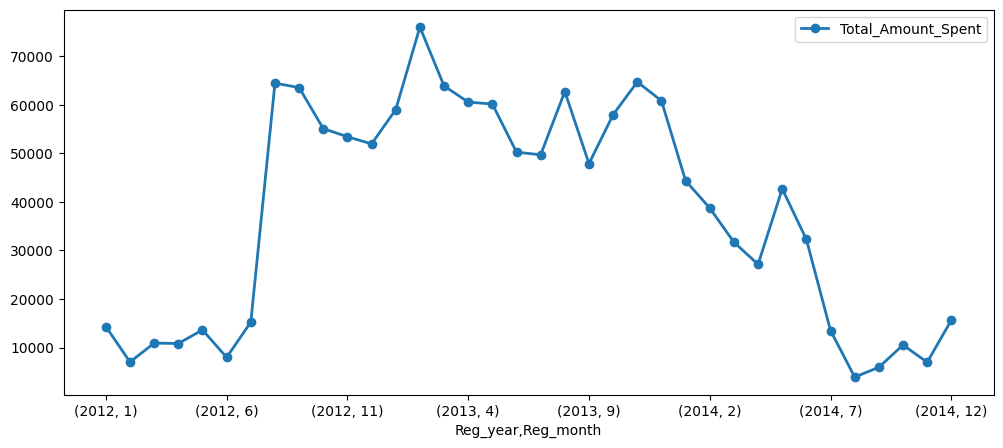

In [52]:
pd.pivot_table(
    data=data,
    index=['Reg_year','Reg_month'],
    values='Total_Amount_Spent',
    aggfunc=np.sum).plot(kind='line', 
                         marker='o',
                         linewidth=2,
                         figsize=(12,5))
plt.show()

- The plot clearly shows that the total amount spent has declined over the years.
- The plot shows the highest increase in the amount spent from August to September 2012. 

#### Total_Amount_Spent vs Income

<Axes: xlabel='Income', ylabel='Total_Amount_Spent'>

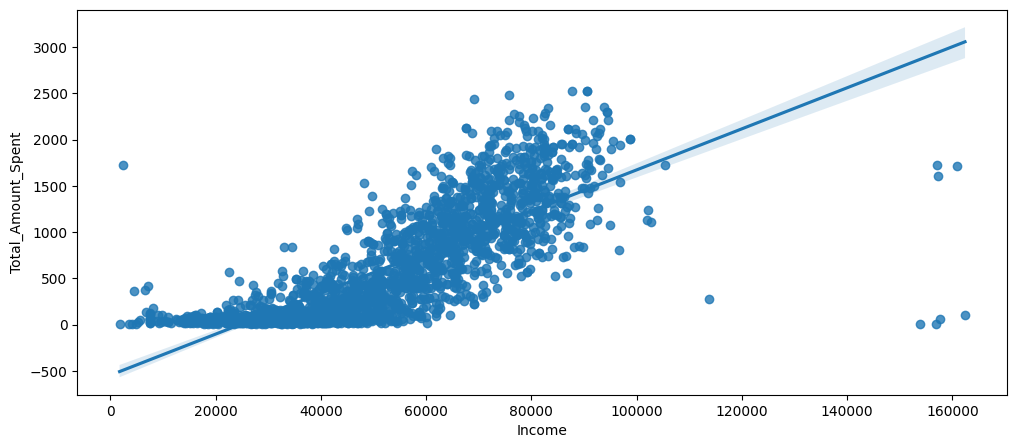

In [53]:
plt.figure(figsize=(12,5))
sns.regplot(x=data['Income'], y=data['Total_Amount_Spent'])

- We can see that income and the total amount spent have a positive correlation.
- The total amount spent is not much different for customers with income in the range of 20K to 60K but the difference is significant for customers in the range of 60K to 100K.

## Data Preprocessing

### Data Preparation for Modeling

In [54]:
data1= data.copy()

In [55]:
data1.drop(columns=[
    'Year_Birth',
    'Dt_Customer',
    'Reg_quarter',
    'Total_Amount_Spent'
], inplace=True)

In [56]:
X = data1.drop(['Response'], axis=1)
y = data1['Response']

X = pd.get_dummies(X, dtype=int)

In [57]:
X.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Age,Reg_year,Reg_month,Reg_week,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Widow
0,84835.000,0,0,0,189,104,379,111,189,218,1,4,4,6,1,0,46,2014,6,2,0,1,0,0,1,0,0,0
1,57091.000,0,0,0,464,5,64,7,0,37,1,7,3,7,5,0,55,2014,6,2,0,1,0,0,0,0,1,0
2,67267.000,0,1,0,134,11,59,15,2,30,1,3,2,5,2,0,58,2014,5,1,0,1,0,0,0,1,0,0
3,32474.000,1,1,0,10,0,1,0,0,0,1,1,0,2,7,0,49,2014,11,0,0,1,0,0,0,1,0,0
4,21474.000,1,0,0,6,16,24,11,0,34,2,3,1,2,7,0,27,2014,8,0,0,1,0,0,0,0,1,0


In [58]:
(X_temp, X_test,
 y_temp, y_test) = train_test_split(X,
                                     y,
                                     test_size=0.2,
                                     random_state=1,
                                     stratify=y)

(X_train, X_val,
 y_train, y_val) = train_test_split(X_temp,
                                    y_temp,
                                    test_size=0.25,
                                    random_state=1,
                                    stratify=y_temp)

print(X_train.shape, X_val.shape, X_train.shape)

(1341, 28) (447, 28) (1341, 28)


### MIssing Value Treatment

In [59]:
imputer = SimpleImputer(strategy='median')

In [60]:
# Fit and transform the training data
X_train = pd.DataFrame(imputer.fit_transform(X_train),
                       columns=X_train.columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val),
                     columns=X_train.columns)

# Transform the testing data
X_test = pd.DataFrame(imputer.transform(X_test),
                     columns=X_train.columns)

In [61]:
# Verify missing values has been corrected
print(X_train.isna().sum())
print('-'*40)
print(X_val.isna().sum())
print('-'*40)
print(X_train.isna().sum())

Income                     0
Kidhome                    0
Teenhome                   0
Recency                    0
MntWines                   0
MntFruits                  0
MntMeatProducts            0
MntFishProducts            0
MntSweetProducts           0
MntGoldProds               0
NumDealsPurchases          0
NumWebPurchases            0
NumCatalogPurchases        0
NumStorePurchases          0
NumWebVisitsMonth          0
Complain                   0
Age                        0
Reg_year                   0
Reg_month                  0
Reg_week                   0
Education_Basic            0
Education_Graduation       0
Education_Master           0
Education_PhD              0
Marital_Status_Divorced    0
Marital_Status_Married     0
Marital_Status_Single      0
Marital_Status_Widow       0
dtype: int64
----------------------------------------
Income                     0
Kidhome                    0
Teenhome                   0
Recency                    0
MntWines          

## Model Building

**Model can make wrong predictions as**:
1. Predicting a customer will buy the product and the customer doesn't buy - Loss of resources
2. Predicting a customer will not buy the product and the customer buys - Loss of opportunity

**Which case is more important?**
* Predicting that customer will not buy the product but he buys i.e. losing on a potential source of income for the company because that customer will not be targeted by the marketing team when he should be targeted.

**How to reduce this loss i.e need to reduce False Negatives?**
* Company wants Recall to be maximized, greater the Recall lesser the chances of false negatives.

In [62]:
scorer = metrics.make_scorer(metrics.recall_score)

In [63]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [64]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Building Initial Models

In [65]:
%%time

models=[]

models.append(('Bagging', BaggingClassifier(random_state=1)))
models.append(('Random forest', RandomForestClassifier(random_state=1)))
models.append(('GBM', GradientBoostingClassifier(random_state=1)))
models.append(('Adaboost', AdaBoostClassifier(random_state=1)))
models.append(('Xgboost', XGBClassifier(random_state=1,
                                        eval_metric='logloss')))
models.append(('dtree', DecisionTreeClassifier(random_state=1)))

results1 = []
names = []

print('\n Cross-Validation performance on training dataset: \n')

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train,
        scoring=scorer, cv=kfold)
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n Validation Performance \n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


 Cross-Validation performance on training dataset: 

Bagging: 0.22000000000000003
Random forest: 0.19499999999999998
GBM: 0.265
Adaboost: 0.39
Xgboost: 0.3350000000000001
dtree: 0.375

 Validation Performance 

Bagging: 0.23880597014925373
Random forest: 0.2537313432835821
GBM: 0.373134328358209
Adaboost: 0.40298507462686567
Xgboost: 0.43283582089552236
dtree: 0.34328358208955223
CPU times: total: 7.62 s
Wall time: 5.93 s


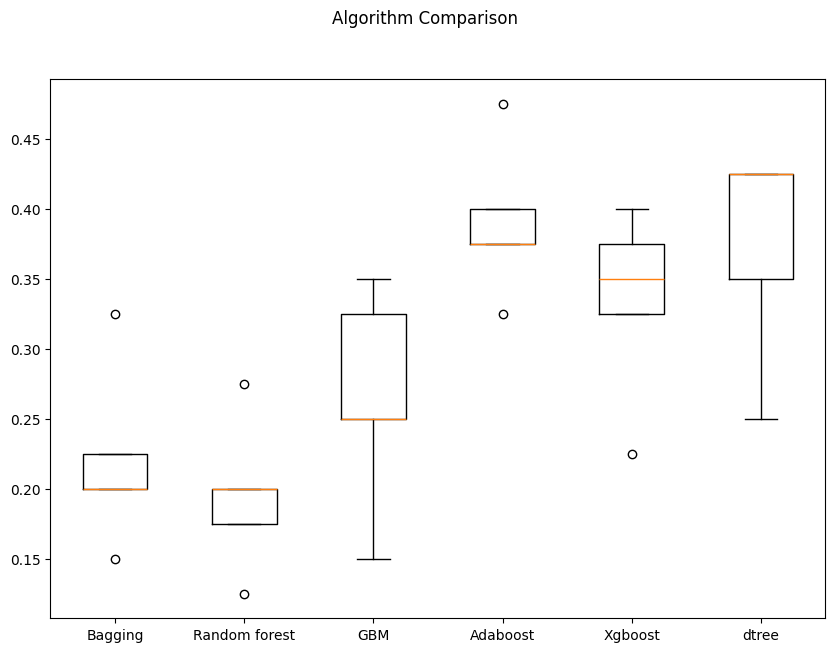

In [66]:
fig = plt.figure(figsize=(10,7))
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)
plt.show()

- We can see that Adaboost is giving the highest cross-validated recall followed by dtree and GBM

- We will tune the Adaboost, dtree, and GBM models and see if the performance improves

## Hyperparameter Tuning

### Adaboost

#### GridSearchCV

In [67]:
%%time

model = AdaBoostClassifier(random_state=1)

parameters = {
    'n_estimators': np.arange(10,110,10),
    'learning_rate': [0.05, 0.01, 0.1, 0.2, 1],
    'estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1)
    ]
}

# scorer was already defined previously

grid_cv = GridSearchCV(estimator=model,
                       param_grid=parameters,
                       scoring=scorer,
                       cv=5,
                       n_jobs=-1).fit(X_train, y_train)

print("Best Parameters: {} \nScore: {}".
     format(grid_cv.best_params_,
            grid_cv.best_score_))

Best Parameters: {'estimator': DecisionTreeClassifier(max_depth=3, random_state=1), 'learning_rate': 1, 'n_estimators': 20} 
Score: 0.395
CPU times: total: 2.34 s
Wall time: 58.6 s


In [68]:
adb_tuned1 = AdaBoostClassifier(
    n_estimators=20,
    learning_rate=1,
    random_state=1,
    estimator=DecisionTreeClassifier(max_depth=3,
                                     random_state=1)).fit(X_train, y_train)

In [69]:
# Calculating different metrics on train set
Adaboost_grid_train = model_performance_classification_sklearn(
    adb_tuned1, X_train, y_train
)
print("Training performance:")
Adaboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.979,0.890,0.967,0.927


In [70]:
# Calculating different metrics on validation set
Adaboost_grid_val = model_performance_classification_sklearn(adb_tuned1, X_val, y_val)
print("Validation performance:")
Adaboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.857,0.403,0.529,0.458


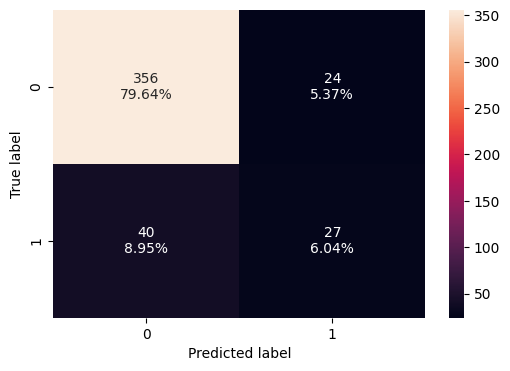

In [71]:
# creating confusion matrix
confusion_matrix_sklearn(adb_tuned1, X_val, y_val)

- The validation recall is similar to cross-validated recall
- The tuned Adaboost model is  overfitting the training data
- The validation recall is still less than 50% i.e. the model is not good at identifying potential customers who would take the offer.

#### RandomizedSearchCV

In [72]:
%%time

model = AdaBoostClassifier(random_state=1)

parameters = {
    'n_estimators': np.arange(10,110,10),
    'learning_rate': [0.05, 0.01, 0.1, 0.2, 1],
    'estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1)
    ]
}

# scorer was already defined previously

randomized_cv = RandomizedSearchCV(estimator=model,
                       param_distributions=parameters,
                       scoring=scorer,
                       cv=5,
                       n_jobs=-1,
                       n_iter=50,
                       random_state=1).fit(X_train, y_train)

print("Best Parameters: {} \nScore: {}".
     format(randomized_cv.best_params_,
            randomized_cv.best_score_))

Best Parameters: {'n_estimators': 20, 'learning_rate': 1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} 
Score: 0.395
CPU times: total: 812 ms
Wall time: 19 s


In [73]:
adb_tuned2 = AdaBoostClassifier(
    n_estimators=20,
    learning_rate=1,
    random_state=1,
    estimator=DecisionTreeClassifier(max_depth=3,
                                     random_state=1)).fit(X_train,
                                                          y_train)

In [74]:
# Calculating different metrics on train set
Adaboost_random_train = model_performance_classification_sklearn(
    adb_tuned2, X_train, y_train
)
print("Training performance:")
Adaboost_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.979,0.890,0.967,0.927


In [75]:
# Calculating different metrics on validation set
Adaboost_random_val = model_performance_classification_sklearn(adb_tuned2, X_val, y_val)
print("Validation performance:")
Adaboost_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.857,0.403,0.529,0.458


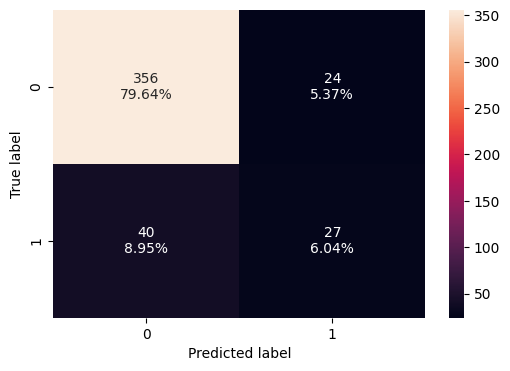

In [76]:
# creating confusion matrix
confusion_matrix_sklearn(adb_tuned2, X_val, y_val)

- Grid search took a significantly longer time than random search. This difference would further increase as the number of parameters increases. 
- The results from both grid and random search are similar

### Decision Tree (dtree)

#### GridSearchCV

In [77]:
dtree_estimator = DecisionTreeClassifier(random_state=1)

parameters = {
    'max_depth': np.arange(10,30,5),
    'min_samples_leaf': [3,5,7],
    'max_leaf_nodes': [2,3,5],
    'min_impurity_decrease': [0.0001, 0.001]
}

# scorer defined earlier

grid_cv = GridSearchCV(estimator=dtree_estimator,
                       param_grid=parameters,
                       scoring=scorer,
                       cv=5, 
                       n_jobs=-1,
                       verbose=2).fit(X_train, y_train)


print("Best parameters are {} with CV score={}:" .
      format(grid_cv.best_params_,
             grid_cv.best_score_))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters are {'max_depth': 10, 'max_leaf_nodes': 5, 'min_impurity_decrease': 0.0001, 'min_samples_leaf': 3} with CV score=0.15499999999999997:


In [78]:
dt_tuned_grid = grid_cv.best_estimator_
dt_tuned_grid.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, max_leaf_nodes=5,
                       min_impurity_decrease=0.0001, min_samples_leaf=3,
                       random_state=1)

In [79]:
dt_grid_train = model_performance_classification_sklearn(
    dt_tuned_grid, X_train, y_train
)
dt_grid_train

,Accuracy,Recall,Precision,F1
0,0.853,0.165,0.524,0.251


In [80]:
dt_grid_val = model_performance_classification_sklearn(
    dt_tuned_grid, X_val, y_val
)
dt_grid_val

,Accuracy,Recall,Precision,F1
0,0.841,0.119,0.400,0.184


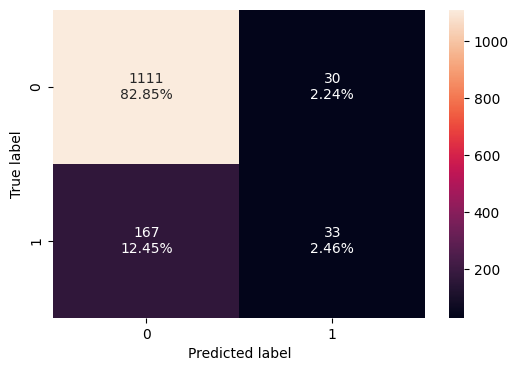

In [81]:
confusion_matrix_sklearn(dt_tuned_grid, X_train, y_train)

- The tuned dtree model is  overfitting the training data
- The validation recall is still less than 50% i.e. the model is not good at identifying potential customers who would take the offer.

#### RandomSearchCV

In [82]:
%%time 

# defining model
model = DecisionTreeClassifier(random_state=1)


# Parameter grid to pass in RandomSearchCV
parameters = {
    'max_depth': np.arange(2, 6),
    'min_samples_leaf': [1,2,3, 4, 7],
    'max_leaf_nodes': [10, 15,20],
    'min_impurity_decrease': [0.0001, 0.001]}

# scorer previously defined

randomized_cv = RandomizedSearchCV(estimator=model,
                                   param_distributions=parameters,
                                   n_jobs=-1,
                                   n_iter=50,
                                   scoring=scorer,
                                   cv=5,
                                   random_state=1).fit(X_train, 
                                                    y_train)
randomized_cv.best_estimator_



CPU times: total: 93.8 ms
Wall time: 854 ms


DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15,
                       min_impurity_decrease=0.001, min_samples_leaf=2,
                       random_state=1)

In [83]:
dt_tuned = randomized_cv.best_estimator_
dt_tuned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15,
                       min_impurity_decrease=0.001, min_samples_leaf=2,
                       random_state=1)

In [84]:
## To check the performance on training set
dt_random_train = model_performance_classification_sklearn(
    dt_tuned, X_train, y_train
)
dt_random_train

,Accuracy,Recall,Precision,F1
0,0.884,0.365,0.716,0.483


In [85]:
## To check the performance on validation set
dt_random_val = model_performance_classification_sklearn(
    dt_tuned, X_val, y_val
)
dt_random_val

,Accuracy,Recall,Precision,F1
0,0.841,0.179,0.429,0.253


- We have received the recall score of 0.365 and 0.179 on the training and the test set, respectively. 
- Model is not generalizing well on both the train and validation dataset

### Gradient Boosting (GBM)

#### GridSearchCV

In [86]:
%%time

model = GradientBoostingClassifier(random_state=1)

parameters = {
    'n_estimators': np.arange(25,100,25),
    'learning_rate': [0.01, 0.05, 0.2, 1],
    'subsample': [0.2, 0.3, 0.4, 0.5],
    'max_features': [0.5, 0.6, 0.7, 0.8]}

grid_cv = GridSearchCV(estimator=model,
                       param_grid=parameters,
                       scoring=scorer,
                       n_jobs=-1,
                       cv=5).fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(grid_cv.best_params_,grid_cv.best_score_))

Best parameters are {'learning_rate': 1, 'max_features': 0.7, 'n_estimators': 25, 'subsample': 0.2} with CV score=0.7050000000000001:
CPU times: total: 1.05 s
Wall time: 31.2 s


In [87]:
grid_cv.best_estimator_

GradientBoostingClassifier(learning_rate=1, max_features=0.7, n_estimators=25,
                           random_state=1, subsample=0.2)

In [88]:
tuned_gbm1 = grid_cv.best_estimator_
tuned_gbm1.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=1, max_features=0.7, n_estimators=25,
                           random_state=1, subsample=0.2)

In [89]:
gbm_grid_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train, y_train
)
gbm_grid_train

,Accuracy,Recall,Precision,F1
0,0.835,0.385,0.440,0.411


In [90]:
gbm_grid_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm_grid_val

,Accuracy,Recall,Precision,F1
0,0.787,0.284,0.288,0.286


- The GBM model on gridsearchCV generalizing well on both train and validation datasets
- The validation recall is ~85% i.e. the model is good at identifying potential customers who would take the offer.

#### RandomSearchCV

In [91]:
%%time

model = GradientBoostingClassifier(random_state=1)

parameters = {
    'n_estimators': np.arange(50,150,25),
    'learning_rate': [0.01, 0.05, 0.2, 1],
    'subsample': [0.3, 0.4, 0.5, 0.6, 0.7],
    'max_features': [0.3, 0.4, 0.5, 0.6, 0.7]}

randomized_cv = RandomizedSearchCV(estimator=model,
                                   param_distributions=parameters,
                                   n_jobs=-1,
                                   n_iter=50,
                                   scoring=scorer,
                                   cv=5,
                                   random_state=1).fit(X_train,
                                                       y_train)

randomized_cv.best_estimator_

CPU times: total: 1.17 s
Wall time: 14 s


GradientBoostingClassifier(learning_rate=1, max_features=0.7, n_estimators=125,
                           random_state=1, subsample=0.5)

In [92]:
tuned_gbm = randomized_cv.best_estimator_
tuned_gbm.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=1, max_features=0.7, n_estimators=125,
                           random_state=1, subsample=0.5)

In [93]:
gbm_random_train= model_performance_classification_sklearn(
    tuned_gbm, X_train, y_train
)
gbm_random_train

,Accuracy,Recall,Precision,F1
0,0.749,0.455,0.285,0.351


In [94]:
gbm_random_val = model_performance_classification_sklearn(tuned_gbm, X_val, y_val)
gbm_random_val

,Accuracy,Recall,Precision,F1
0,0.745,0.433,0.276,0.337


## Model Performance Comparison and Final Model Selection

In [95]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        Adaboost_grid_train.T,
        Adaboost_random_train.T,
        gbm_grid_train.T,
        gbm_random_train.T,
        dt_grid_train.T,
        dt_random_train.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "AdaBoost Tuned with Grid search",
    "AdaBoost Tuned with Random search",
    "Gradient Boosting Tuned with Grid search",
    "Gradient Boosting Tuned with Random search",
    "Decision tree with grid search",
    "Decision tree with random search",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,AdaBoost Tuned with Grid search,AdaBoost Tuned with Random search,Gradient Boosting Tuned with Grid search,Gradient Boosting Tuned with Random search,Decision tree with grid search,Decision tree with random search
Accuracy,0.979,0.979,0.835,0.749,0.853,0.884
Recall,0.890,0.890,0.385,0.455,0.165,0.365
Precision,0.967,0.967,0.440,0.285,0.524,0.716
F1,0.927,0.927,0.411,0.351,0.251,0.483


In [96]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        Adaboost_grid_val.T,
        Adaboost_random_val.T,
        gbm_grid_val.T,
        gbm_random_val.T,
        dt_grid_val.T,
        dt_random_val.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "AdaBoost Tuned with Grid search",
    "AdaBoost Tuned with Random search",
    "Gradient Boosting Tuned with Grid search",
    "Gradient Boosting Tuned with Random search",
    "Decision tree with grid search",
    "Decision tree with random search",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,AdaBoost Tuned with Grid search,AdaBoost Tuned with Random search,Gradient Boosting Tuned with Grid search,Gradient Boosting Tuned with Random search,Decision tree with grid search,Decision tree with random search
Accuracy,0.857,0.857,0.787,0.745,0.841,0.841
Recall,0.403,0.403,0.284,0.433,0.119,0.179
Precision,0.529,0.529,0.288,0.276,0.400,0.429
F1,0.458,0.458,0.286,0.337,0.184,0.253


In [97]:
# Calculating different metrics on the test set
gbm_grid_test = model_performance_classification_sklearn(tuned_gbm1, X_test, y_test)
print("Test performance:")
gbm_grid_test

Test performance:


,Accuracy,Recall,Precision,F1
0,0.797,0.373,0.338,0.355


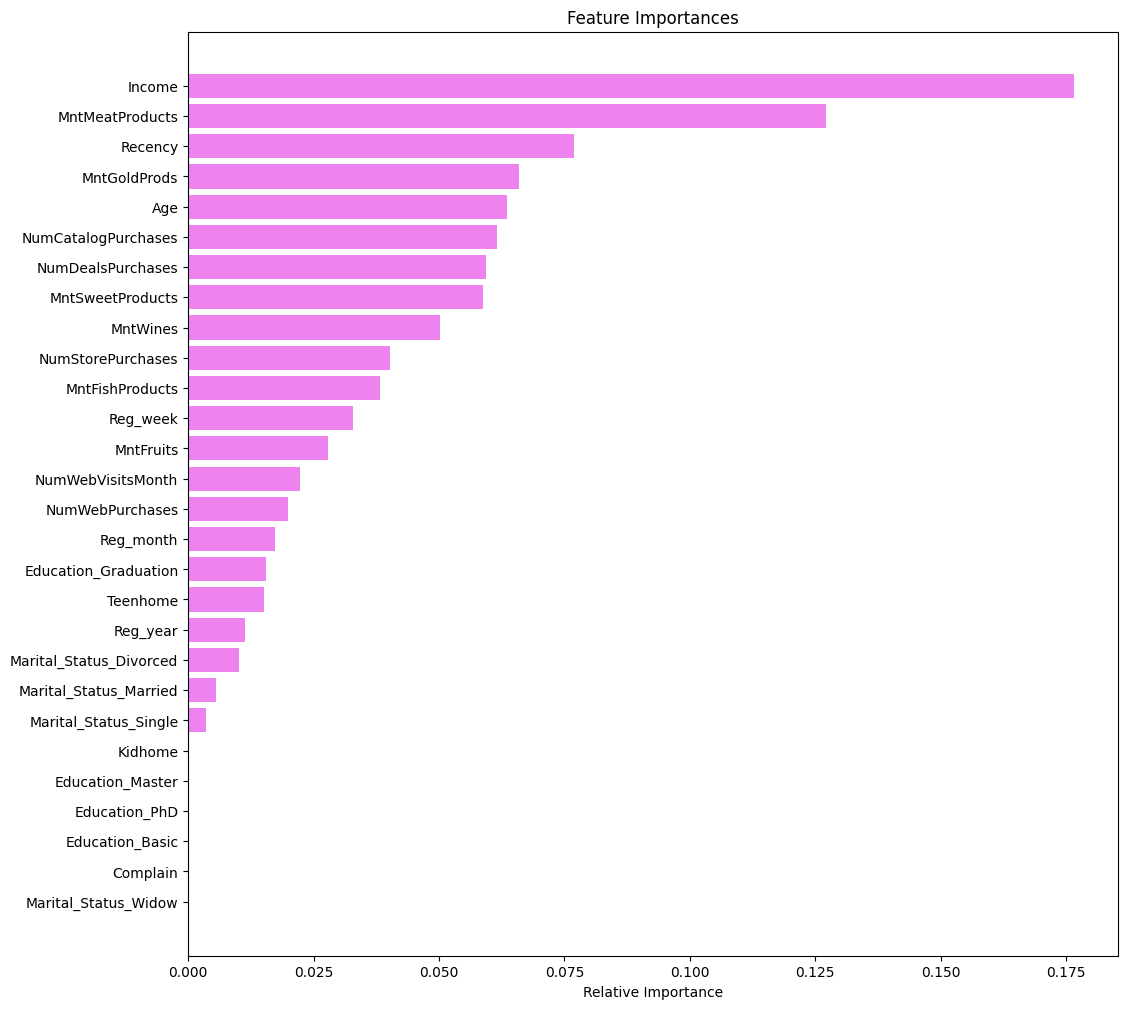

In [98]:
feature_names = X.columns
importances = tuned_gbm1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Pipelines

In [103]:
numerical_features = [
    'Income',
    'Kidhome',
    'Teenhome',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Complain',
    'Age',
    'Reg_year',
    'Reg_month',
    'Reg_week'
]

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))])

categorical_features = [
    'Education',
    'Marital_Status'
]

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder = 'passthrough')

In [104]:
X = data1.drop(columns='Response')
y = data1['Response']

In [105]:
(X_train, X_test,
 y_train, y_test) = train_test_split(X,
                                     y,
                                     test_size=0.2,
                                     random_state=1,
                                     stratify=y)
print(X_train.shape, X_test.shape)

(1788, 22) (448, 22)


In [106]:
# Creating new pipeline with best parameters
model = Pipeline(
    steps=[
        ("pre", preprocessor),
        (
            "GBM",
            GradientBoostingClassifier(
            max_features=0.7,
            random_state=1,
            learning_rate=1,
            n_estimators=50,
            subsample=0.2
        ),
        ),
    ]
)
# Fit the model on training data
model.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Income', 'Kidhome',
                                                   'Teenhome', 'Recency',
                                                   'MntWines', 'MntFruits',
                                                   'MntMeatProducts',
                                                   'MntFishProducts',
                                                   'MntSweetProducts',
                                                   'MntGoldProds',
                                                   'NumDealsPurchases',
                                                   'NumWebPurchases',
                                                   'NumCatalogPurchases',
                                                   'NumSto...
                                                   'NumWebVisitsMonth',
                                                   'Complain', 'Age',
                                                   'Reg_year', 'Reg_month',
                                                   'Reg_week']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Education',
                                                   'Marital_Status'])])),
                ('GBM',
                 GradientBoostingClassifier(learning_rate=1, max_features=0.7,
                                            n_estimators=50, random_state=1,
                                            subsample=0.2))])

In [107]:
# Let's check the performance on test set
Model_test = model_performance_classification_sklearn(model, X_test, y_test)
Model_test

,Accuracy,Recall,Precision,F1
0,0.708,0.358,0.214,0.268
